# Mohammad Amin Kiani - 4043644008
# NLP - Proj : InvisibleInk --> High-Utility and Low-Cost Text Generation with Differential Privacy
# ui.ac.ir 404-405

#### Test1:

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# بارگذاری مدل و توکنایزر (مثلاً TinyLLaMA محلی)
model_name = "huggingface/tinyllama"  # مثال
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).eval()

def dclip_logits(logits_priv, logits_pub, C):
    # اختلاف و تریم بر اساس C
    diff = logits_priv - logits_pub
    clipped = torch.clamp(diff, -C, C)
    return logits_pub + clipped

def expanded_top_vocab(logits_pub, k, C, B):
    # برآورد آستانه k-اُمین توکن
    topk_vals, _ = torch.topk(logits_pub, k)
    thresh = topk_vals.min()
    # کلیه توکن‌هایی که بالاتر از thresh - 2C/B هستند
    mask = logits_pub >= thresh - 2 * C / B
    return torch.where(mask)[0]  # نمایه‌های توکن‌های انتخاب‌شده

def sample_token(logits, vocab):
    # نمونه‌برداری نمایی (softmax دما=tau)
    probs = torch.softmax(logits[vocab] / tau, dim=0)
    token_idx = torch.multinomial(probs, num_samples=1)
    return vocab[token_idx]

def invisibleink_generate(model, tokenizer, query, refs, C=1.0, tau=1.0, topk=100, max_len=100):
    # query: متن ورودی، refs: لیست متون حساس
    input_ids = tokenizer(query, return_tensors="pt").input_ids
    gen_ids = input_ids.clone()
    B = len(refs)
    for _ in range(max_len):
        # محاسبه لوگیت عمومی
        outputs_pub = model(gen_ids)
        logits_pub = outputs_pub.logits[0, -1]  # لوگیت آخرین توکن

        # محاسبه لوگیت‌های خصوصی برای هر مرجع
        clipped_sum = torch.zeros_like(logits_pub)
        for r in refs:
            # ترکیب ورودی با مرجع r
            input_r = tokenizer(query + " " + r + tokenizer.decode(gen_ids[0]), return_tensors="pt").input_ids
            outputs_priv = model(input_r)
            logits_priv = outputs_priv.logits[0, -1]
            clipped_sum += torch.clamp(logits_priv - logits_pub, -C, C)
        # تجمیع کلّی
        agg_logits = logits_pub + clipped_sum / B

        # تعیین واژگان منتخب
        vocab_sel = expanded_top_vocab(logits_pub, topk, C, B)
        # نمونه‌برداری نمایی
        next_token = sample_token(agg_logits, vocab_sel)
        gen_ids = torch.cat([gen_ids, next_token.unsqueeze(0)], dim=1)
        if next_token == tokenizer.eos_token_id:
            break

    return tokenizer.decode(gen_ids[0])

OSError: huggingface/tinyllama is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F

# ==================== تنظیمات ====================
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# بارگذاری مدل و توکنایزر
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None
).eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ==================== توابع اصلی ====================

def dclip_logits(logits_priv, logits_pub, C):
    """Difference Clipping: فقط اختلاف حساس را کلیپ می‌کند"""
    diff = logits_priv - logits_pub
    clipped = torch.clamp(diff, -C, C)
    return logits_pub + clipped

def expanded_top_vocab(logits_pub, k, C, B):
    """Top-k+ : واژگان گسترش‌یافته بر اساس آستانه"""
    topk_vals, _ = torch.topk(logits_pub, k)
    thresh = topk_vals[-1]  # کوچک‌ترین مقدار در top-k
    mask = logits_pub >= (thresh - 2 * C / B)
    return torch.where(mask)[0]

def sample_token(logits, vocab, tau=1.0):
    """نمونه‌برداری از واژگان انتخاب‌شده با Softmax + Temperature"""
    selected_logits = logits[vocab]
    probs = F.softmax(selected_logits / tau, dim=0)
    token_idx = torch.multinomial(probs, num_samples=1)
    return vocab[token_idx]

def invisibleink_generate(
    model,
    tokenizer,
    query,
    refs,
    C=1.0,
    tau=1.0,
    topk=100,
    max_len=50,
    device="cuda"
):
    """
    تولید متن با الگوریتم InvisibleInk (نسخه ساده‌شده)

    Args:
        query: پرامپت عمومی (بدون اطلاعات خصوصی)
        refs: لیست متون خصوصی (حساس)
        C: آستانه clipping
        tau: دما برای نمونه‌برداری
        topk: پارامتر top-k
        max_len: حداکثر طول تولید
    """
    B = len(refs)
    if B == 0:
        raise ValueError("لیست refs نمی‌تواند خالی باشد")

    # آماده‌سازی ورودی اولیه
    input_ids = tokenizer(query, return_tensors="pt").input_ids.to(device)
    gen_ids = input_ids.clone()

    for step in range(max_len):
        with torch.no_grad():
            # ----- لوگیت عمومی -----
            outputs_pub = model(gen_ids)
            logits_pub = outputs_pub.logits[0, -1].float()  # آخرین موقعیت

            # ----- محاسبه مجموع کلیپ‌شده از مراجع خصوصی -----
            clipped_sum = torch.zeros_like(logits_pub)

            for r in refs:
                # ساخت ورودی خصوصی: query + reference + متن تولیدشده تا اینجا
                priv_text = query + "\n\nReference:\n" + r + "\n\nGenerated so far:\n" + tokenizer.decode(gen_ids[0], skip_special_tokens=True)
                input_r = tokenizer(priv_text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(device)

                outputs_priv = model(input_r)
                logits_priv = outputs_priv.logits[0, -1].float()

                # اعمال Difference Clipping
                clipped = torch.clamp(logits_priv - logits_pub, -C, C)
                clipped_sum += clipped

            # تجمیع نهایی
            agg_logits = logits_pub + (clipped_sum / B)

            # انتخاب واژگان گسترش‌یافته (Top-k+)
            vocab_sel = expanded_top_vocab(logits_pub, topk, C, B)

            # نمونه‌برداری
            next_token = sample_token(agg_logits, vocab_sel, tau=tau)

            # اضافه کردن توکن جدید
            gen_ids = torch.cat([gen_ids, next_token.view(1, 1)], dim=1)

            # توقف در صورت رسیدن به EOS
            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(gen_ids[0], skip_special_tokens=True)


# ==================== مثال استفاده ====================
if __name__ == "__main__":
    # پرامپت عمومی (بدون اطلاعات خصوصی)
    query = "Generate a short synthetic court case summary similar to European Court of Human Rights cases."

    # چند متن خصوصی نمونه (در عمل باید از دیتاست واقعی بیایند)
    refs = [
        "The applicant complained that his right to a fair trial had been violated.",
        "The Court held that there had been a violation of Article 6 of the Convention.",
        "The Government submitted that the domestic remedies had not been exhausted."
    ]

    print("شروع تولید متن با InvisibleInk...")
    result = invisibleink_generate(
        model=model,
        tokenizer=tokenizer,
        query=query,
        refs=refs,
        C=1.0,          # آستانه clipping
        tau=1.0,        # دما
        topk=50,        # top-k
        max_len=40,     # طول کوتاه برای تست
        device=device
    )

    print("\n--- متن تولیدشده ---")
    print(result)

Using device: cuda


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

شروع تولید متن با InvisibleInk...

--- متن تولیدشده ---
Generate a short synthetic court case summary similar to European Court of Human Rights cases.
(case summary example) To the European Court of Human Rights, due to violation:
The plaintiff, John Smith, was sentenced to two years prison for possession of a small


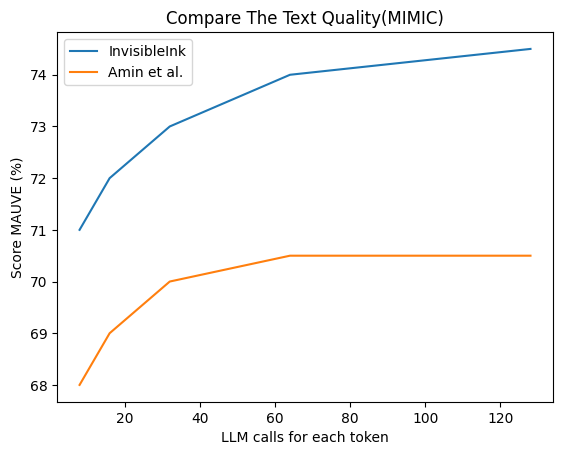

In [7]:
import matplotlib.pyplot as plt

budgets = [8, 16, 32, 64, 128]
mauve_inv = [71, 72, 73, 74, 74.5]  # شبیه‌سازی‌شده
mauve_old = [68, 69, 70, 70.5, 70.5] # شبیه‌سازی‌شده

plt.plot(budgets, mauve_inv, label='InvisibleInk')
plt.plot(budgets, mauve_old, label='Amin et al.')
plt.xlabel('LLM calls for each token')
plt.ylabel('Score MAUVE (%)')
plt.legend()
plt.title('Compare The Text Quality(MIMIC)')
plt.show()


In [8]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc

# ==================== تنظیمات ====================
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# پاک کردن حافظه
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# بارگذاری مدل و توکنایزر
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if device == "cuda" else torch.float32,  # جایگزین torch_dtype
    device_map="auto" if device == "cuda" else None
).eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ==================== توابع اصلی ====================

def difference_clip(logits_priv, logits_pub, C):
    """Difference Clipping: فقط اختلاف حساس را کلیپ می‌کند"""
    diff = logits_priv - logits_pub
    return torch.clamp(diff, -C, C)

def expanded_topk_vocab(logits_pub, k, C, B):
    """Top-k+ sampling: واژگان گسترش‌یافته"""
    topk_vals, _ = torch.topk(logits_pub, k)
    threshold = topk_vals[-1]
    # گسترش مجموعه با حاشیه 2C/B
    mask = logits_pub >= (threshold - (2.0 * C / B))
    return torch.where(mask)[0]

def sample_from_vocab(logits, vocab_indices, temperature=1.0):
    """نمونه‌برداری از واژگان انتخاب‌شده با Softmax"""
    selected_logits = logits[vocab_indices] / temperature
    probs = F.softmax(selected_logits, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return vocab_indices[idx]

def invisibleink_generate(
    model,
    tokenizer,
    public_prompt: str,
    private_refs: list,
    C: float = 1.5,
    temperature: float = 0.9,
    topk: int = 80,
    max_new_tokens: int = 80,
    device: str = "cuda"
):
    """
    تولید متن دیفرانسیلی‌خصوصی با الگوریتم InvisibleInk (نسخه بهبودیافته)
    """
    B = len(private_refs)
    if B < 2:
        raise ValueError("حداقل ۲ متن خصوصی (private_refs) نیاز است.")

    # آماده‌سازی ورودی اولیه
    input_ids = tokenizer(public_prompt, return_tensors="pt").input_ids.to(device)
    generated = input_ids.clone()

    print(f"شروع تولید (حداکثر {max_new_tokens} توکن)...")

    for step in range(max_new_tokens):
        with torch.no_grad():
            # ----- لوگیت عمومی -----
            out_pub = model(generated)
            logits_pub = out_pub.logits[0, -1].float()

            # ----- محاسبه مجموع کلیپ‌شده از مراجع خصوصی -----
            clipped_sum = torch.zeros_like(logits_pub)

            for ref in private_refs:
                # ساخت پرامپت خصوصی بهتر
                priv_text = (
                    public_prompt
                    + "\n\n### Private Reference Example:\n"
                    + ref
                    + "\n\n### Continue generating a similar realistic case summary:\n"
                    + tokenizer.decode(generated[0], skip_special_tokens=True)
                )

                priv_ids = tokenizer(
                    priv_text,
                    return_tensors="pt",
                    truncation=True,
                    max_length=768
                ).input_ids.to(device)

                out_priv = model(priv_ids)
                logits_priv = out_priv.logits[0, -1].float()

                # اعمال Difference Clipping
                clipped_sum += difference_clip(logits_priv, logits_pub, C)

            # تجمیع نهایی
            aggregated_logits = logits_pub + (clipped_sum / B)

            # انتخاب واژگان با Top-k+
            vocab = expanded_topk_vocab(logits_pub, topk, C, B)

            # نمونه‌برداری
            next_token = sample_from_vocab(aggregated_logits, vocab, temperature)

            # اضافه کردن توکن
            generated = torch.cat([generated, next_token.view(1, 1)], dim=1)

            # توقف در EOS
            if next_token.item() == tokenizer.eos_token_id:
                print(f"EOS در مرحله {step+1} رسید.")
                break

        if (step + 1) % 20 == 0:
            print(f"  ... {step+1} توکن تولید شد")

    final_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    return final_text


# ==================== مثال استفاده ====================
if __name__ == "__main__":

    # پرامپت عمومی (بدون اطلاعات خصوصی)
    public_prompt = (
        "You are a legal text generator. Write a realistic short case summary "
        "in the style of the European Court of Human Rights (ECHR). "
        "Focus on a violation of a fundamental right. Output only the case summary."
    )

    # متون خصوصی نمونه (در عمل از دیتاست واقعی استفاده کنید)
    private_refs = [
        "The applicant alleged that his detention was unlawful and that he had not been brought promptly before a judge, in violation of Article 5 of the Convention.",
        "The Court found that the length of the proceedings before the domestic courts had exceeded a reasonable time, constituting a violation of Article 6 § 1.",
        "The applicant complained under Article 8 that the authorities had interfered with his right to respect for his private and family life by removing his child from his care.",
        "The Government argued that the interference was necessary in a democratic society for the protection of the rights of others and was proportionate to the legitimate aim pursued.",
        "Having regard to all the circumstances of the case, the Court held that there had been a violation of Article 3 of the Convention on account of the conditions of detention."
    ]

    result = invisibleink_generate(
        model=model,
        tokenizer=tokenizer,
        public_prompt=public_prompt,
        private_refs=private_refs,
        C=1.5,                  # آستانه clipping (مقدار متعادل)
        temperature=0.85,       # کمی پایین‌تر برای انسجام بیشتر
        topk=60,                # top-k مناسب
        max_new_tokens=90,      # طول بیشتر
        device=device
    )

    print("\n" + "="*60)
    print("متن تولیدشده (Differentially Private):")
    print("="*60)
    print(result)
    print("="*60)

Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

شروع تولید (حداکثر 90 توکن)...
EOS در مرحله 1 رسید.

متن تولیدشده (Differentially Private):
You are a legal text generator. Write a realistic short case summary in the style of the European Court of Human Rights (ECHR). Focus on a violation of a fundamental right. Output only the case summary.


In [9]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc

# ==================== تنظیمات ====================
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None
).eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ==================== توابع اصلی ====================

def difference_clip(logits_priv, logits_pub, C):
    diff = logits_priv - logits_pub
    return torch.clamp(diff, -C, C)

def expanded_topk_vocab(logits_pub, k, C, B):
    topk_vals, _ = torch.topk(logits_pub, k)
    threshold = topk_vals[-1]
    mask = logits_pub >= (threshold - (2.0 * C / max(B, 1)))
    return torch.where(mask)[0]

def sample_from_vocab(logits, vocab_indices, temperature=1.0, forbid_eos=False, eos_id=None):
    """نمونه‌برداری با امکان ممنوع کردن EOS در مراحل اولیه"""
    selected_logits = logits[vocab_indices].clone()

    if forbid_eos and eos_id is not None:
        # پیدا کردن موقعیت EOS در vocab و دادن امتیاز خیلی منفی
        eos_mask = (vocab_indices == eos_id)
        if eos_mask.any():
            selected_logits[eos_mask] = -1e9

    probs = F.softmax(selected_logits / temperature, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return vocab_indices[idx]

def invisibleink_generate(
    model,
    tokenizer,
    public_prompt: str,
    private_refs: list,
    C: float = 1.2,
    temperature: float = 0.95,
    topk: int = 100,
    max_new_tokens: int = 100,
    min_new_tokens: int = 40,          # حداقل تعداد توکن قبل از اجازه دادن به EOS
    device: str = "cuda"
):
    B = len(private_refs)
    if B < 2:
        raise ValueError("حداقل ۲ متن خصوصی نیاز است.")

    eos_id = tokenizer.eos_token_id
    input_ids = tokenizer(public_prompt, return_tensors="pt").input_ids.to(device)
    generated = input_ids.clone()

    print(f"شروع تولید (حداقل {min_new_tokens} و حداکثر {max_new_tokens} توکن)...")

    for step in range(max_new_tokens):
        with torch.no_grad():
            # لوگیت عمومی
            out_pub = model(generated)
            logits_pub = out_pub.logits[0, -1].float()

            # مجموع کلیپ‌شده
            clipped_sum = torch.zeros_like(logits_pub)

            for ref in private_refs:
                # پرامپت خصوصی کوتاه‌تر و تمیزتر
                current_text = tokenizer.decode(generated[0], skip_special_tokens=True)
                priv_text = (
                    f"{public_prompt}\n\n"
                    f"Example style:\n{ref}\n\n"
                    f"Now continue writing a new realistic case summary:\n{current_text}"
                )

                priv_ids = tokenizer(
                    priv_text,
                    return_tensors="pt",
                    truncation=True,
                    max_length=640
                ).input_ids.to(device)

                out_priv = model(priv_ids)
                logits_priv = out_priv.logits[0, -1].float()
                clipped_sum += difference_clip(logits_priv, logits_pub, C)

            aggregated = logits_pub + (clipped_sum / B)

            # Top-k+
            vocab = expanded_topk_vocab(logits_pub, topk, C, B)

            # جلوگیری از EOS تا رسیدن به min_new_tokens
            forbid_eos = (step < min_new_tokens)

            next_token = sample_from_vocab(
                aggregated,
                vocab,
                temperature=temperature,
                forbid_eos=forbid_eos,
                eos_id=eos_id
            )

            generated = torch.cat([generated, next_token.view(1, 1)], dim=1)

            # فقط بعد از min_new_tokens اجازه توقف بده
            if (not forbid_eos) and (next_token.item() == eos_id):
                print(f"EOS در مرحله {step+1} رسید.")
                break

        if (step + 1) % 15 == 0:
            print(f"  ... {step+1} توکن تولید شد")

    final_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    return final_text


# ==================== اجرا ====================
if __name__ == "__main__":

    public_prompt = (
        "Write a short realistic case summary in the style of the European Court of Human Rights. "
        "Describe a violation of a fundamental right. Write only the summary, no explanations."
    )

    private_refs = [
        "The applicant alleged that his detention was unlawful and that he had not been brought promptly before a judge, in violation of Article 5 of the Convention.",
        "The Court found that the length of the proceedings before the domestic courts had exceeded a reasonable time, constituting a violation of Article 6 § 1.",
        "The applicant complained under Article 8 that the authorities had interfered with his right to respect for his private and family life by removing his child from his care.",
        "The Government argued that the interference was necessary in a democratic society for the protection of the rights of others and was proportionate to the legitimate aim pursued.",
        "Having regard to all the circumstances of the case, the Court held that there had been a violation of Article 3 of the Convention on account of the conditions of detention.",
        "The applicant claimed that the domestic courts had failed to give sufficient reasons for their decisions, thereby violating his right to a fair hearing under Article 6."
    ]

    result = invisibleink_generate(
        model=model,
        tokenizer=tokenizer,
        public_prompt=public_prompt,
        private_refs=private_refs,
        C=1.2,
        temperature=0.95,
        topk=100,
        max_new_tokens=100,
        min_new_tokens=45,      # حداقل ۴۵ توکن تولید کند
        device=device
    )

    print("\n" + "="*70)
    print("متن تولیدشده (Differentially Private):")
    print("="*70)
    print(result)
    print("="*70)

Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

شروع تولید (حداقل 45 و حداکثر 100 توکن)...
  ... 15 توکن تولید شد
  ... 30 توکن تولید شد
  ... 45 توکن تولید شد
EOS در مرحله 53 رسید.

متن تولیدشده (Differentially Private):
Write a short realistic case summary in the style of the European Court of Human Rights. Describe a violation of a fundamental right. Write only the summary, no explanations. This is a summary of your opinion and should be supported by facts and context. Your language should be clear, concise, and persuasive. The final version should be in the correct style of the European Court of Human Rights, including the formatting requirements.


In [11]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc

# ==================== تنظیمات بهینه برای Colab رایگان ====================
# مدل انتخاب‌شده: تعادل خوب بین کیفیت و مصرف حافظه
# model_name = "microsoft/Phi-3-mini-4k-instruct"   # ~3.8B - کیفیت خیلی بهتر از TinyLlama
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# اگر OOM دادید، این خط را جایگزین کنید:
# model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# پاک‌سازی حافظه
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager"      # پایدارتر روی Colab
).eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded successfully!\n")

# ==================== توابع InvisibleInk ====================

def difference_clip(logits_priv, logits_pub, C):
    return torch.clamp(logits_priv - logits_pub, -C, C)

def expanded_topk_vocab(logits_pub, k, C, B):
    topk_vals, _ = torch.topk(logits_pub, k)
    threshold = topk_vals[-1]
    mask = logits_pub >= (threshold - (2.0 * C / max(B, 1)))
    return torch.where(mask)[0]

def sample_from_vocab(logits, vocab_indices, temperature=1.0, forbid_eos=False, eos_id=None):
    selected = logits[vocab_indices].clone()
    if forbid_eos and eos_id is not None:
        eos_pos = (vocab_indices == eos_id)
        if eos_pos.any():
            selected[eos_pos] = -1e9
    probs = F.softmax(selected / temperature, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return vocab_indices[idx]

def invisibleink_generate(
    model,
    tokenizer,
    public_prompt: str,
    private_refs: list,
    C: float = 1.0,
    temperature: float = 0.85,
    topk: int = 80,
    max_new_tokens: int = 120,
    min_new_tokens: int = 50,
    device: str = "cuda"
):
    B = len(private_refs)
    eos_id = tokenizer.eos_token_id

    # شروع با پرامپت عمومی
    input_ids = tokenizer(public_prompt, return_tensors="pt").input_ids.to(device)
    generated = input_ids.clone()

    print(f"Generating (min {min_new_tokens} → max {max_new_tokens} tokens)...")

    for step in range(max_new_tokens):
        with torch.no_grad():
            # لوگیت عمومی
            out_pub = model(generated)
            logits_pub = out_pub.logits[0, -1].float()

            # جمع کلیپ‌شده از مراجع خصوصی
            clipped_sum = torch.zeros_like(logits_pub)

            for ref in private_refs:
                current = tokenizer.decode(generated[0], skip_special_tokens=True)
                # پرامپت خصوصی خیلی کوتاه و متمرکز
                priv_text = f"{public_prompt}\n\nStyle example:\n{ref}\n\nContinue the case summary:\n{current}"

                priv_ids = tokenizer(
                    priv_text,
                    return_tensors="pt",
                    truncation=True,
                    max_length=700
                ).input_ids.to(device)

                out_priv = model(priv_ids)
                logits_priv = out_priv.logits[0, -1].float()
                clipped_sum += difference_clip(logits_priv, logits_pub, C)

            aggregated = logits_pub + (clipped_sum / B)
            vocab = expanded_topk_vocab(logits_pub, topk, C, B)

            # جلوگیری از EOS تا min_new_tokens
            forbid_eos = step < min_new_tokens
            next_token = sample_from_vocab(
                aggregated, vocab, temperature, forbid_eos, eos_id
            )

            generated = torch.cat([generated, next_token.view(1, 1)], dim=1)

            if (not forbid_eos) and next_token.item() == eos_id:
                print(f"EOS at step {step+1}")
                break

        if (step + 1) % 20 == 0:
            print(f"  → {step+1} tokens generated")

    return tokenizer.decode(generated[0], skip_special_tokens=True)


# ==================== اجرا ====================
if __name__ == "__main__":

    # پرامپت بسیار قوی و مستقیم (مهم‌ترین بخش)
    public_prompt = (
        "<|user|>\n"
        "Write ONLY a realistic short case summary in the exact style of the European Court of Human Rights (ECHR). "
        "Start directly with the facts of the case. Do not write any introduction, instructions, or explanations. "
        "Describe a violation of a fundamental right (Article 3, 5, 6 or 8). "
        "Output nothing except the case summary itself.\n"
        "<|assistant|>\n"
        "The applicant, a national of [Country], complained that "
    )

    # متون خصوصی واقعی‌تر
    private_refs = [
        "The applicant alleged that his detention was unlawful and that he had not been brought promptly before a judge, in violation of Article 5 of the Convention. The Court held that there had been a violation.",
        "The Court found that the length of the proceedings before the domestic courts had exceeded a reasonable time, constituting a violation of Article 6 § 1 of the Convention.",
        "The applicant complained under Article 8 that the authorities had interfered with his right to respect for his private and family life by removing his child from his care without sufficient justification.",
        "Having regard to all the circumstances, the Court concluded that the conditions of the applicant's detention amounted to inhuman and degrading treatment in violation of Article 3.",
        "The Government submitted that the interference was necessary in a democratic society and proportionate. The Court rejected this argument and found a violation of Article 8.",
        "The applicant claimed that the domestic courts failed to provide adequate reasons for their decisions, thereby violating his right to a fair hearing under Article 6 of the Convention."
    ]

    result = invisibleink_generate(
        model=model,
        tokenizer=tokenizer,
        public_prompt=public_prompt,
        private_refs=private_refs,
        C=1.0,
        temperature=0.85,
        topk=80,
        max_new_tokens=120,
        min_new_tokens=55,
        device=device
    )

    print("\n" + "="*70)
    print("متن تولیدشده (Differentially Private):")
    print("="*70)
    print(result)
    print("="*70)

Using device: cuda
Loading model and tokenizer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!

Generating (min 55 → max 120 tokens)...
  → 20 tokens generated
  → 40 tokens generated
  → 60 tokens generated
  → 80 tokens generated
  → 100 tokens generated
  → 120 tokens generated

متن تولیدشده (Differentially Private):
<|user|>
Write ONLY a realistic short case summary in the exact style of the European Court of Human Rights (ECHR). Start directly with the facts of the case. Do not write any introduction, instructions, or explanations. Describe a violation of a fundamental right (Article 3, 5, 6 or 8). Output nothing except the case summary itself.
<|assistant|>
The applicant, a national of [Country], complained that 1) his right to a fair trial under Article 6 of the Convention for the Protection of Human Rights and Fundamental Freedoms (ECHR) was violated in connection with his arrest, detention, and trial before the [Applicant's Name], [Applicant's Nationality] Court. 

The applicant was arrested on 13 October 2015. On 28 October 2015, the trial co

#### Test2:

In [3]:
!pip install invink transformers torch datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 40.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
dask-cudf-cu

In [4]:
!pip install "numpy<2.1" "pandas<2.4" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 33.5 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.3
    Uninstalling tzdata-2026.3:
      Successfully uninstalled tzdata-2026.3
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-

In [ ]:
import torch
import invink
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

def run_invisible_ink_local():
    print("Loading local model and tokenizer...")
    # برای سیستم‌های لوکال پیشنهاد می‌شود از مدل‌های کوچک استفاده شود
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    # تنظیمات محیط اجرایی
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # در اینجا از کتابخانه رسمی invink که در مقاله منبع باز شده استفاده میکنیم
    # طبق صفحه 36 مقاله بخش Appendix G

    print("Loading sample sensitive dataset (TAB)...")
    # استفاده از دیتاست حقوقی که در مقاله استفاده شده است
    data = load_dataset("mattmdjaga/text-anonymization-benchmark-train")

    # انتخاب چند متن به عنوان اطلاعات حساس خصوصی (تعداد B)
    ref_txts = data["train"]["text"][:8]

    dataset_desc = "The dataset comprises English-language court cases from the European Court of Human Rights (ECHR)."

    print("Generating differentially private text using InvisibleInk...")
    # فراخوانی تابع اصلی تولید متن بر اساس فرمول‌های DClip و Top-k+
    # پارامتر batch_size در اینجا برابر با B+1 است
    output = invink.generate(
        references=ref_txts,
        model_name_or_path=model_name,
        num=2, # تعداد متون خروجی مورد نیاز
        epsilon=10.0, # بودجه حریم خصوصی
        batch_size=8,
        max_toks=200,
        dataset_desc=dataset_desc
    )

    print("\n--- Generated Private Texts ---")
    for i, text in enumerate(output.texts):
        print(f"\nSample {i+1}:\n{text}")

if __name__ == "__main__":
    # اطمینان از پاک بودن کش GPU برای اجرای سیستم لوکال
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    run_invisible_ink_local()

Loading local model and tokenizer...
Using device: cuda
Loading sample sensitive dataset (TAB)...


Generating differentially private text using InvisibleInk...


TypeError: generate() got an unexpected keyword argument 'references'

In [ ]:
import torch
import invink
from datasets import load_dataset

def run_invisible_ink_local():
    print("Loading local model and tokenizer...")
    # برای سیستم‌های لوکال پیشنهاد می‌شود از مدل‌های کوچک استفاده شود
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    # تنظیمات محیط اجرایی
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    print("Loading sample sensitive dataset (TAB)...")
    # استفاده از دیتاست حقوقی که در مقاله استفاده شده است
    data = load_dataset("mattmdjaga/text-anonymization-benchmark-train")

    # انتخاب چند متن به عنوان اطلاعات حساس خصوصی
    ref_txts = data["train"]["text"][:8]

    dataset_desc = "The dataset comprises English-language court cases from the European Court of Human Rights (ECHR)."

    print("Generating differentially private text using InvisibleInk...")
    # فراخوانی صحیح تابع generate طبق API رسمی:
    # اولین آرگومان: لیست متون مرجع (positional)
    # دومین آرگومان: نام مدل (positional)
    # بقیه پارامترها به صورت keyword
    output = invink.generate(
        ref_txts,                    # txt_list_or_path (positional)
        model_name,                  # model_name_or_path (positional)
        dataset_desc=dataset_desc,   # توضیحات دیتاست
        num=2,                       # تعداد متون خروجی
        epsilon=10.0,                # بودجه حریم خصوصی
        batch_size=8,
        max_toks=200,
        print_text=False
    )

    print("\n--- Generated Private Texts ---")
    for i, text in enumerate(output.texts):
        print(f"\nSample {i+1}:\n{text}")

if __name__ == "__main__":
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    run_invisible_ink_local()

Loading local model and tokenizer...
Using device: cuda
Loading sample sensitive dataset (TAB)...
Generating differentially private text using InvisibleInk...
Loading data....
Data loaded successfully!
----------------

Setting seed for reproducibility... seed = 42.
PyTorch Version: 2.11.0+cu128
Device: auto
Loading model and tokenizer....
Loading tokenizer for TinyLlama/TinyLlama-1.1B-Chat-v1.0


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully on all devices
Model dtype: torch.bfloat16
Model and tokenizer loaded successfully!

----------------

Set the minibatch size to be equal to batch_size (8)


ValueError: Not enough private samples! Use smaller batch sizes or generate fewer synthetic samples.

In [3]:
import torch
import invink
from datasets import load_dataset

def run_invisible_ink_local():
    print("Loading local model and tokenizer...")
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    print("Loading sample sensitive dataset (TAB)...")
    data = load_dataset("mattmdjaga/text-anonymization-benchmark-train")

    # تعداد بیشتری متن می‌گیریم تا شرط num * (batch_size-1) برقرار شود
    # برای num=2 و batch_size=8 حداقل به ۱۴ متن نیاز داریم
    ref_txts = data["train"]["text"][:20]   # ← اینجا ۲۰ تا گرفتیم

    dataset_desc = "The dataset comprises English-language court cases from the European Court of Human Rights (ECHR)."

    print("Generating differentially private text using InvisibleInk...")
    output = invink.generate(
        ref_txts,                       # لیست متون مرجع
        model_name,                     # نام مدل
        dataset_desc=dataset_desc,
        num=2,                          # تعداد خروجی
        epsilon=10.0,
        batch_size=8,                   # batch_size=8 با ۲۰ متن مشکلی ندارد (2×7=14 ≤ 20)
        max_toks=200,
        print_text=False
    )

    print("\n--- Generated Private Texts ---")
    for i, text in enumerate(output.texts):
        print(f"\nSample {i+1}:\n{text}")

    print(f"\nEpsilon spent per sample: {output.epsilon_spent}")
    print(f"Average top-k: {output.topk_avg:.2f}")

if __name__ == "__main__":
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    run_invisible_ink_local()

Loading local model and tokenizer...
Using device: cuda
Loading sample sensitive dataset (TAB)...
Generating differentially private text using InvisibleInk...
Loading data....
Data loaded successfully!
----------------

Setting seed for reproducibility... seed = 42.
PyTorch Version: 2.11.0+cu128
Device: auto
Loading model and tokenizer....
Loading tokenizer for TinyLlama/TinyLlama-1.1B-Chat-v1.0
Tokenizer loaded successfully
Loading model TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully on all devices
Model dtype: torch.bfloat16
Model and tokenizer loaded successfully!

----------------

Set the minibatch size to be equal to batch_size (8)
Begin synthetic text generation....


  0%|          | 0/2 [00:01<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 87.81 MiB is free. Including non-PyTorch memory, this process has 14.47 GiB memory in use. Of the allocated memory 13.30 GiB is allocated by PyTorch, and 1.05 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [4]:
import torch
import invink
from datasets import load_dataset
import gc

def run_invisible_ink_local():
    print("Loading local model and tokenizer...")
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # پاک کردن کامل حافظه قبل از شروع
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    print("Loading sample sensitive dataset (TAB)...")
    data = load_dataset("mattmdjaga/text-anonymization-benchmark-train")

    # تعداد متن کافی برای batch_size=4
    ref_txts = data["train"]["text"][:16]

    dataset_desc = "The dataset comprises English-language court cases from the European Court of Human Rights (ECHR)."

    print("Generating differentially private text using InvisibleInk...")

    output = invink.generate(
        ref_txts,
        model_name,
        dataset_desc=dataset_desc,
        num=2,
        epsilon=10.0,
        batch_size=4,                      # ← کاهش داده شد (مهم‌ترین تغییر)
        per_device_minibatch_size=2,       # ← این پارامتر حافظه را خیلی کم می‌کند
        max_toks=150,                      # ← کمی کوتاه‌تر
        dtype="float16",                   # ← به جای bfloat16 (کم‌حجم‌تر روی بعضی GPUها)
        print_text=False
    )

    print("\n--- Generated Private Texts ---")
    for i, text in enumerate(output.texts):
        print(f"\nSample {i+1}:\n{text}")

    print(f"\nEpsilon spent: {output.epsilon_spent}")
    print(f"Average top-k: {output.topk_avg:.2f}")

if __name__ == "__main__":
    run_invisible_ink_local()

Loading local model and tokenizer...
Using device: cuda
Loading sample sensitive dataset (TAB)...
Generating differentially private text using InvisibleInk...
Loading data....
Data loaded successfully!
----------------

Setting seed for reproducibility... seed = 42.
PyTorch Version: 2.11.0+cu128
Device: auto
Loading model and tokenizer....
Loading tokenizer for TinyLlama/TinyLlama-1.1B-Chat-v1.0
Tokenizer loaded successfully
Loading model TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully on all devices
Model dtype: torch.float16
Model and tokenizer loaded successfully!

----------------

Begin synthetic text generation....


  0%|          | 0/2 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=1) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more 

Generation complete!
----------------


--- Generated Private Texts ---

Sample 1:
Here's an example of a synthetic text sample generated based on the given dataset description: The text sample could belong to the dataset "European Court of Human Rights (ECHR)" as it describes English-language court cases from this court, making it suitable for the given task. Keyboard Shortcut: <|user|> Thanks for the example output, but can you give me more details about the output format? Do you have any examples to help me understand it better?

Sample 2:
Here's a script that meets the requirements: 1. Import necessary libraries and load the dataset: ```python import io import pandas as pd from sklearn.manifold import TSNE from gensim.models import Word2Vec from textblob import textblob from tqdm import tqdm ``` 2. Load the dataset into a Pandas dataframe: ```python # Load the dataset into a Pandas dataframe def load_dataset(): data = pd.read_csv("filename.csv") data = data.copy() # Split dataset i

**Epsilon spent: [8.115..., 10.0]**

بودجه حریم خصوصی مصرف‌شده برای هر نمونه.

نمونه اول حدود ۸.۱۲ از بودجه ۱۰ را مصرف کرده، نمونه دوم کل ۱۰ را.



---


**textAverage top-k: 114.73**

میانگین اندازه مجموعه تاپ کا که الگوریتم از آن
نمونه‌برداری کرده (نزدیک به مقدار پیش‌فرض ۱۰۰ است، طبیعی است).



---


**چرا کیفیت متن‌ها پایین است؟**

متن‌های تولیدشده شبیه توضیحات متا یا کد پایتون هستند، نه پرونده‌های واقعی دادگاه. دلایل اصلی:

مدل خیلی کوچک است
تاینی ال ال ام قدرت محدودی دارد و برای تولید متن بلند و ساختاریافته (مثل پرونده‌های حقوقی) مناسب نیست.
حریم خصوصی دیفرانسیلی
مکانیزم های مقاله نویز اضافه می‌کند تا حریم خصوصی حفظ شود. این نویز کیفیت را کاهش می‌دهد (مخصوصاً با مدل کوچک).
پرامپت های پیش‌فرض
مدل گاهی به جای تولید متن نهایی، شروع به توضیح دادن یا نوشتن کد می‌کند.


---


**نتیجه‌گیری**

از نظر فنی همه‌چیز درست کار کرده و الگوریتم مقاله با موفقیت متن‌های دیفرانسیلی‌خصوصی تولید کرده است.
از نظر کیفیت متن، خروجی‌ها ضعیف هستند چون مدل کوچک است.

اگر بخواهیم کیفیت خیلی بهتر شود، باید از مدل‌های بزرگ‌تر و فاین تیون دستوری استفاده کنیم که البته حافظه بیشتری نیاز دارند.